In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error


In [3]:
df = pd.read_csv("LahoreDivision_Tehsil_Rainfall_1995_2025.csv")
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date")
df.head()


,system:index,adm0_name,adm0_name1,adm0_name2,adm0_name3,adm0_pcode,adm1_name,adm1_name1,adm1_name2,adm1_name3,...,lang1,lang2,lang3,mean,month,rainfall_mm,valid_on,year,.geo,date
0,0_00000000000000000000,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,NaN,17.931617,1.0,17.931617,1662706800000,1995.0,"{""type"":""Polygon"",""coordinates"":[[[73.77759720...",1995-01-01
1,0_00000000000000000001,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,NaN,19.371417,1.0,19.371417,1662706800000,1995.0,"{""type"":""Polygon"",""coordinates"":[[[74.13133321...",1995-01-01
2,0_00000000000000000002,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,NaN,16.252826,1.0,16.252826,1662706800000,1995.0,"{""type"":""Polygon"",""coordinates"":[[[73.65624272...",1995-01-01
3,0_00000000000000000003,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,NaN,22.403328,1.0,22.403328,1662706800000,1995.0,"{""type"":""Polygon"",""coordinates"":[[[74.27960280...",1995-01-01
4,0_00000000000000000004,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,NaN,18.107872,1.0,18.107872,1662706800000,1995.0,"{""type"":""Polygon"",""coordinates"":[[[74.00348633...",1995-01-01


In [4]:
def train_tehsil_model(tehsil_name):
    data = df[df["adm3_name"] == tehsil_name].copy()
    data = data.set_index("date")
    ts = data["rainfall_mm"]
    split = int(len(ts) * 0.7)
    train = ts[:split]
    test = ts[split:]
    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit()
    forecast = results.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"{tehsil_name} RMSE:", rmse)

    plt.figure(figsize=(10,5))
    plt.plot(train, label="Train")
    plt.plot(test, label="Actual")
    plt.plot(forecast, label="Predicted")
    plt.title(f"Rainfall Pattern — {tehsil_name}")
    plt.legend()
    plt.show()

    return results



Training model for: Chunian


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Chunian RMSE: 35.40574579363184


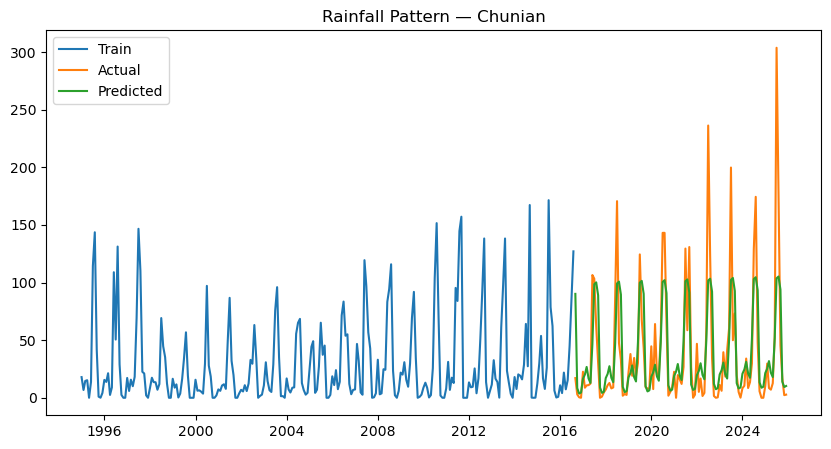


Training model for: Kasur


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kasur RMSE: 39.15188036895195


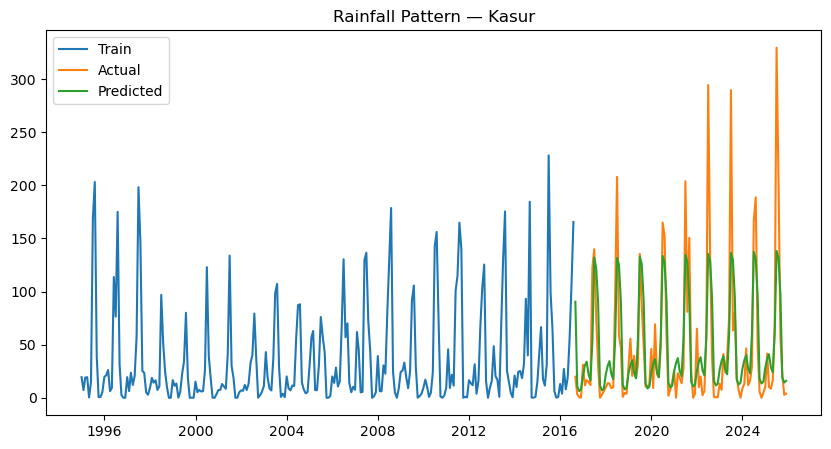


Training model for: Pattoki


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Pattoki RMSE: 42.37461706451334


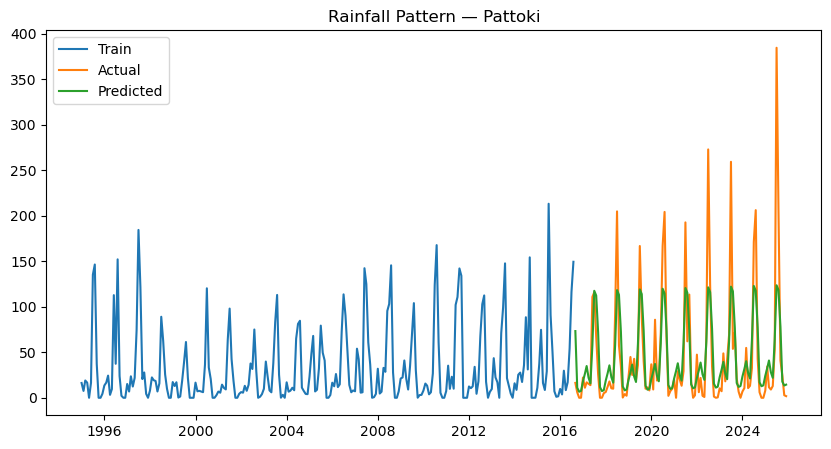


Training model for: Lahore Cantt


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Lahore Cantt RMSE: 54.032743858061934


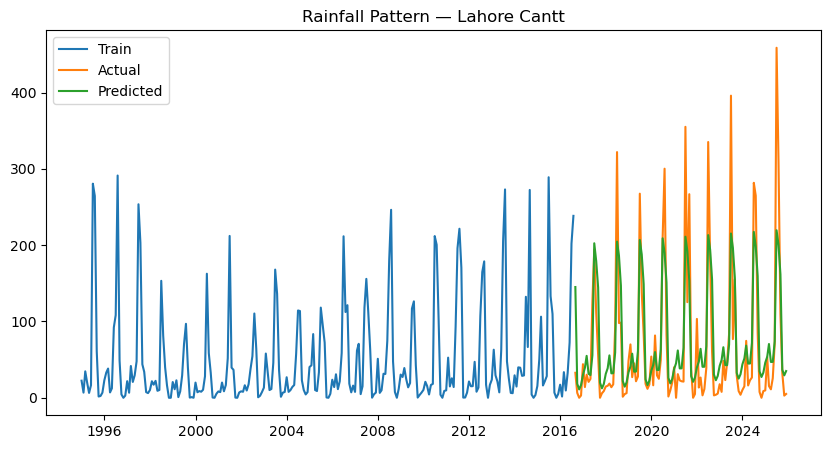


Training model for: Lahore City


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Lahore City RMSE: 50.04432214776625


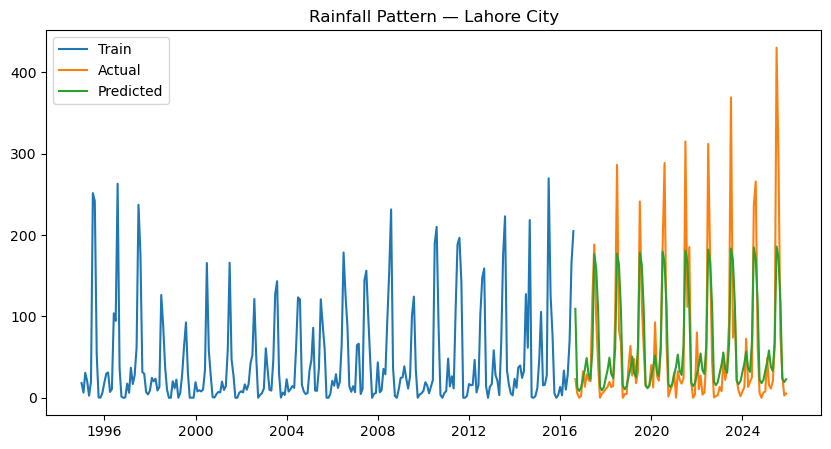


Training model for: Nankana Sahib


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Nankana Sahib RMSE: 41.222878269629916


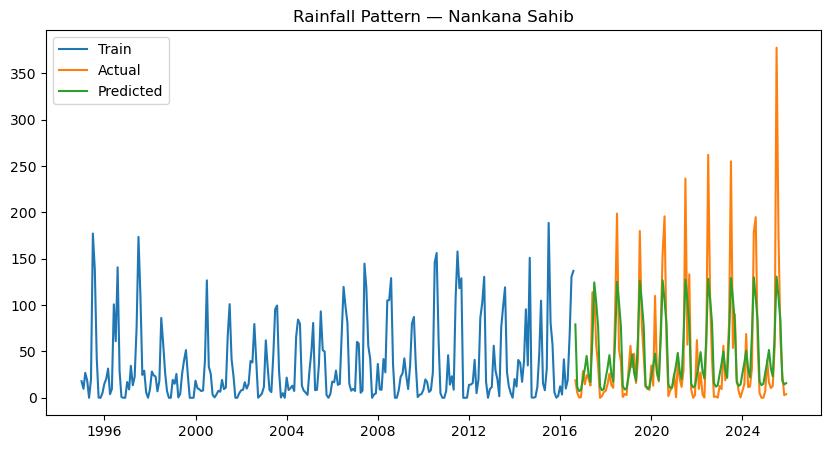


Training model for: Sangla Hill


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Sangla Hill RMSE: 29.959706749730827


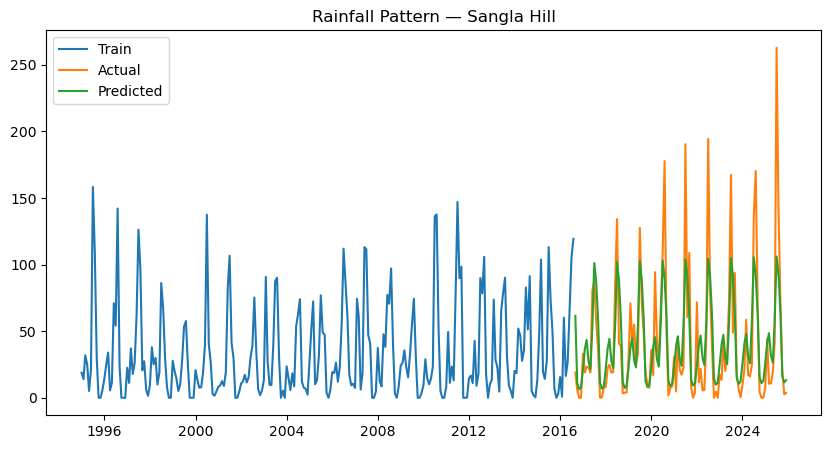


Training model for: Ferozewala


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Ferozewala RMSE: 49.93218284182833


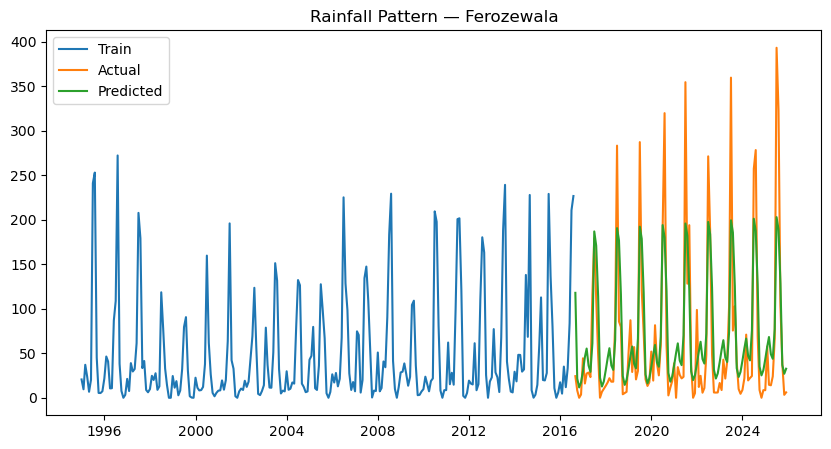


Training model for: Muridke


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Muridke RMSE: 51.07288206606649


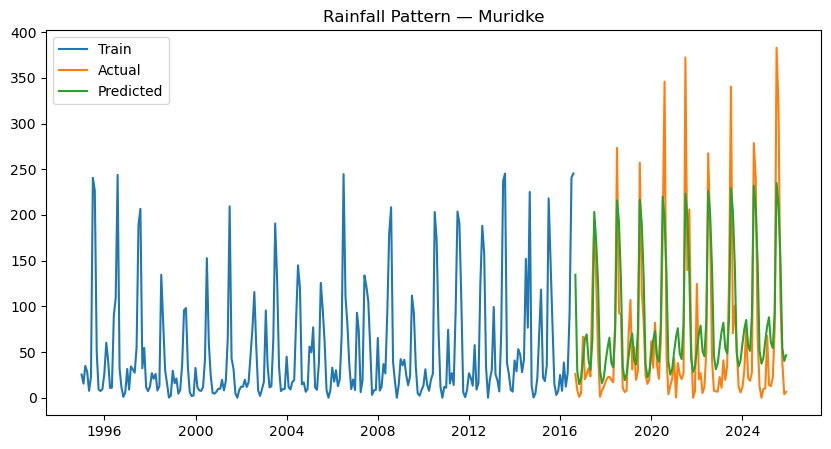


Training model for: Safdarabad


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Safdarabad RMSE: 33.05880953960061


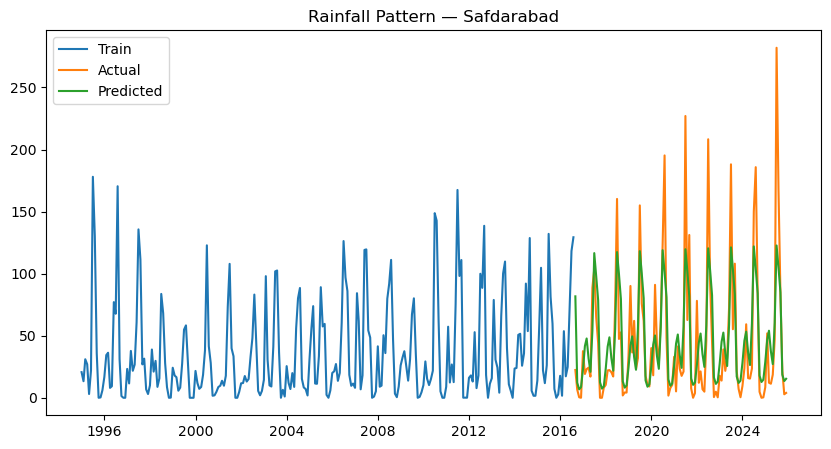


Training model for: Sheikhupura


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Sheikhupura RMSE: 37.98682418016677


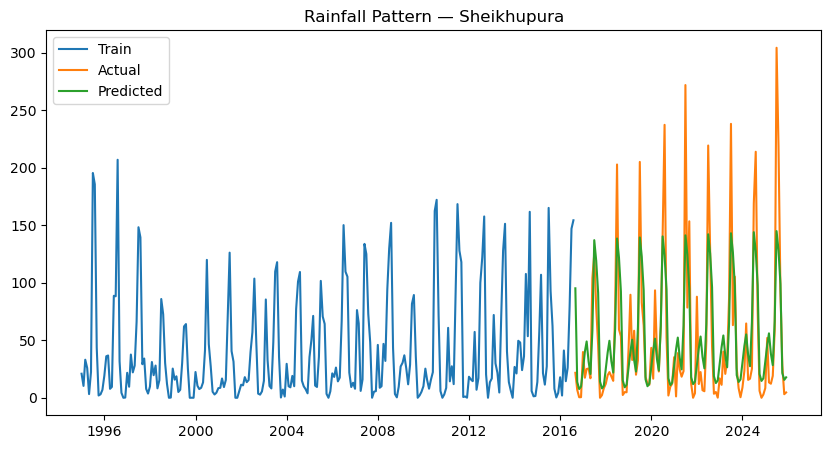

In [5]:
tehsils = df["adm3_name"].unique()

models = {}

for t in tehsils:
    print("\nTraining model for:", t)
    models[t] = train_tehsil_model(t)
